# 02 - Metrics Anomaly Detection

Build a leakage-aware statistical detection pipeline for CPU, memory, and network telemetry. Application and MongoDB metrics are kept separate, and canonical series are selected before aggregation to avoid double counting.

## 1. Configuration and scenario setup

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

SCENARIO_ID = "ts-auth-mongo_4.4.15_2022-07-13"

# Hỗ trợ chạy notebook từ thư mục notebooks/ hoặc project root
PROJECT_ROOT = Path("..") if Path("../data/raw").exists() else Path(".")
SCENARIO_DIR = PROJECT_ROOT / "data" / "raw" / SCENARIO_ID

RESAMPLE_INTERVAL = "30s"
MAX_COUNTER_GAP_SECONDS = 90

CPU_METRIC = "container_cpu_usage_seconds_total"
MEMORY_METRIC = "container_memory_working_set_bytes"
NETWORK_METRIC = "container_network_transmit_packets_total"

TARGET_METRICS = {
    CPU_METRIC,
    MEMORY_METRIC,
    NETWORK_METRIC,
}

print("Scenario:", SCENARIO_DIR.resolve())
assert SCENARIO_DIR.exists(), f"Scenario không tồn tại: {SCENARIO_DIR}"

Scenario: E:\AIO\Project\aiops-trainticket-pipeline\data\raw\ts-auth-mongo_4.4.15_2022-07-13


## 2. Load canonical metric series

Select container-level CPU and memory series, pod-level network series, and classify them as application or MongoDB telemetry.

#### What does canonical series mean?

A Prometheus metric file contains many labeled time series, including multiple views of the same Kubernetes workload. For example, CPU or memory may be reported for the application container, the whole pod cgroup, and the infrastructure sandbox. Adding all of those views would count part of the same resource more than once. A **canonical series** is the single, intentionally selected view that this notebook treats as the source of truth for a metric.

The selection rule depends on the metric:

- **CPU and memory:** use the actual workload container (`ts-auth-service` or `ts-auth-mongo`) and exclude pod-level and sandbox series.
- **Network:** use `container=POD` because containers in a Kubernetes pod share the pod network namespace; identify the owner from the `pod` label.
- Keep the authentication application (`application`) and its database (`mongo`) as separate entities.

This section produces two different tables:

- `series_inventory`: one row per selected time series, used to inspect labels and sample counts. It does not contain individual metric values.
- `raw_metrics`: one row per timestamped sample, including the raw `value` used by later transformation and detection steps.

At this stage the six logical groups (three metrics × two entities) are appended vertically in long format. They have not been merged into six value columns.

In [2]:
def classify_series(labels):
    """
    Chọn đúng entity và đúng cấp metric để tránh double counting.
    """
    metric_name = labels.get("__name__")
    pod = str(labels.get("pod") or "")
    container = labels.get("container")

    if metric_name not in TARGET_METRICS:
        return None

    # CPU và memory: lấy container-level
    if metric_name in {CPU_METRIC, MEMORY_METRIC}:
        if container == "ts-auth-service":
            return "application"

        if container == "ts-auth-mongo":
            return "mongo"

        return None

    # Network: lấy pod network namespace
    if metric_name == NETWORK_METRIC and container == "POD":
        if pod.startswith("ts-auth-service-"):
            return "application"

        if pod.startswith("ts-auth-mongo-"):
            return "mongo"

    return None


metric_files = sorted(
    p
    for folder in SCENARIO_DIR.glob("Monitoring_*")
    for p in folder.glob("*.json")
)

rows = []
series_inventory = []

for file in metric_files:
    document = json.loads(file.read_text(encoding="utf-8"))

    for index, series in enumerate(document["data"]["result"]):
        labels = series.get("metric", {})
        entity = classify_series(labels)

        if entity is None:
            continue

        metric_name = labels["__name__"]
        series_id = f"{file.name}:{index}"

        values = series.get("values", [])

        series_inventory.append({
            "series_id": series_id,
            "entity": entity,
            "metric_name": metric_name,
            "pod": labels.get("pod"),
            "container": labels.get("container"),
            "image": labels.get("image"),
            "instance": labels.get("instance"),
            "sample_count": len(values),
        })

        for timestamp, value in values:
            rows.append({
                "timestamp": pd.to_datetime(
                    float(timestamp),
                    unit="s",
                    utc=True,
                ),
                "value": pd.to_numeric(value, errors="coerce"),
                "series_id": series_id,
                "entity": entity,
                "metric_name": metric_name,
                "pod": labels.get("pod"),
                "container": labels.get("container"),
                "image": labels.get("image"),
                "instance": labels.get("instance"),
            })

raw_metrics = (
    pd.DataFrame(rows)
    .sort_values(["series_id", "timestamp"])
    .reset_index(drop=True)
)

series_inventory = pd.DataFrame(series_inventory)

print("Selected samples:", len(raw_metrics))
display(series_inventory)

Selected samples: 751


,series_id,entity,metric_name,pod,container,image,instance,sample_count
0,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,53
1,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-df88ffc66-fhd5t,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.22:10250,1
2,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6f9dfd688d-wgl8s,ts-auth-mongo,docker.io/library/mongo:5.0.9,10.252.1.23:10250,65
3,ts-auth-service_3_Mongo_4.4.15.json_container_...,application,container_cpu_usage_seconds_total,ts-auth-service-96d95d474-bdfpt,ts-auth-service,docker.io/codewisdom/ts-auth-service-with-jaeg...,10.252.1.21:10250,53
4,ts-auth-service_3_Mongo_4.4.15.json_container_...,application,container_cpu_usage_seconds_total,ts-auth-service-b794cb6bb-cpx5q,ts-auth-service,docker.io/codewisdom/ts-auth-service-with-jaeg...,10.252.1.23:10250,77
5,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_memory_working_set_bytes,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,54
6,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_memory_working_set_bytes,ts-auth-mongo-df88ffc66-fhd5t,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.22:10250,2
7,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_memory_working_set_bytes,ts-auth-mongo-6f9dfd688d-wgl8s,ts-auth-mongo,docker.io/library/mongo:5.0.9,10.252.1.23:10250,65
8,ts-auth-service_3_Mongo_4.4.15.json_container_...,application,container_memory_working_set_bytes,ts-auth-service-96d95d474-bdfpt,ts-auth-service,docker.io/codewisdom/ts-auth-service-with-jaeg...,10.252.1.21:10250,55
9,ts-auth-service_3_Mongo_4.4.15.json_container_...,application,container_memory_working_set_bytes,ts-auth-service-b794cb6bb-cpx5q,ts-auth-service,docker.io/codewisdom/ts-auth-service-with-jaeg...,10.252.1.23:10250,77


## 3. Validate series selection

Verify that container-level and pod-level resource views are not mixed accidentally.

In [3]:
selection_summary = (
    series_inventory
    .groupby(["entity", "metric_name"], dropna=False)
    .agg(
        series_count=("series_id", "nunique"),
        pod_count=("pod", "nunique"),
        containers=("container", lambda x: sorted(x.dropna().unique())),
        sample_count=("sample_count", "sum"),
    )
    .reset_index()
)

display(selection_summary)

cpu_memory = series_inventory[
    series_inventory["metric_name"].isin({
        CPU_METRIC,
        MEMORY_METRIC,
    })
]

network = series_inventory[
    series_inventory["metric_name"].eq(NETWORK_METRIC)
]

# CPU/memory không được chứa pod-level hoặc sandbox
assert not cpu_memory["container"].isin(["POD"]).any()
assert cpu_memory["container"].notna().all()

# Network phải lấy ở pod network namespace
assert network["container"].eq("POD").all()

# Mỗi series chỉ thuộc một entity
assert (
    series_inventory
    .groupby("series_id")["entity"]
    .nunique()
    .max()
    == 1
)

print("Canonical-series validation passed.")

,entity,metric_name,series_count,pod_count,containers,sample_count
0,application,container_cpu_usage_seconds_total,2,2,[ts-auth-service],130
1,application,container_memory_working_set_bytes,2,2,[ts-auth-service],132
2,application,container_network_transmit_packets_total,2,2,[POD],130
3,mongo,container_cpu_usage_seconds_total,3,3,[ts-auth-mongo],119
4,mongo,container_memory_working_set_bytes,3,3,[ts-auth-mongo],121
5,mongo,container_network_transmit_packets_total,3,3,[POD],119


Canonical-series validation passed.


## 4. Transform counters and gauges

Convert CPU and network counters to per-second rates and memory bytes to MiB, independently for each time series.

In [ ]:
def transform_series(group):
    # Sắp xếp dữ liệu theo thời gian để diff() được tính đúng thứ tự
    group = group.sort_values("timestamp").copy()

    # Mỗi group tương ứng một series nên chỉ có một loại metric
    metric_name = group["metric_name"].iloc[0]

    # Khoảng thời gian giữa mẫu hiện tại và mẫu trước, đơn vị giây
    group["elapsed_seconds"] = (
        group["timestamp"]
        .diff()
        .dt.total_seconds()
    )

    # Mức thay đổi của giá trị so với mẫu trước
    # Hữu ích với metric dạng counter như CPU và network
    group["counter_delta"] = group["value"].diff()

    # Khởi tạo các cờ kiểm tra chất lượng dữ liệu
    group["counter_reset"] = False
    group["invalid_gap"] = False

    # CPU và network là counter tích lũy nên cần chuyển thành tốc độ
    if metric_name in {CPU_METRIC, NETWORK_METRIC}:

        # Counter giảm thường có nghĩa container/process đã restart
        group["counter_reset"] = group["counter_delta"].lt(0)

        # Khoảng lấy mẫu không hợp lệ nếu:
        # - Bằng hoặc nhỏ hơn 0 giây
        # - Lớn hơn ngưỡng cho phép, ở đây là 90 giây
        group["invalid_gap"] = (
            group["elapsed_seconds"].le(0)
            | group["elapsed_seconds"].gt(MAX_COUNTER_GAP_SECONDS)
        )

        # Chuyển counter tích lũy thành tốc độ trên mỗi giây
        # CPU: CPU-seconds / second = số CPU core sử dụng
        # Network: packets / second
        group["signal_value"] = (
            group["counter_delta"]
            / group["elapsed_seconds"]
        )

        # Xác định những mẫu không đủ tin cậy để phân tích
        invalid = (
            group["counter_reset"]                 # Counter vừa bị reset
            | group["invalid_gap"]                 # Khoảng thời gian không hợp lệ
            | group["elapsed_seconds"].isna()      # Mẫu đầu tiên không có mẫu trước
        )

        # Đánh dấu giá trị không hợp lệ bằng NaN
        group.loc[invalid, "signal_value"] = np.nan

        # Gán đơn vị tương ứng với từng loại metric
        group["unit"] = (
            "cpu_cores"
            if metric_name == CPU_METRIC
            else "packets_per_second"
        )

    # Memory là gauge: giá trị tại thời điểm đo, không cần tính diff()
    elif metric_name == MEMORY_METRIC:

        # Chuyển đơn vị từ byte sang MiB
        group["signal_value"] = group["value"] / (1024 ** 2)
        group["unit"] = "MiB"

    # Trả về series đã được bổ sung các trường xử lý
    return group


# Danh sách chứa kết quả biến đổi của từng time series
transformed_groups = []

# Tách dữ liệu theo series_id để không tính diff() giữa hai series khác nhau
for _, group in raw_metrics.groupby("series_id", sort=False):
    transformed_groups.append(transform_series(group))

# Ghép tất cả series đã xử lý thành một DataFrame
transformed = (
    pd.concat(transformed_groups, ignore_index=True)
    # Sắp xếp lại để dữ liệu dễ đọc và xử lý ở các bước sau
    .sort_values(["series_id", "timestamp"])
)


# Tổng hợp thông tin chất lượng dữ liệu theo thành phần và loại metric
quality_summary = (
    transformed
    .groupby(["entity", "metric_name"])
    .agg(
        # Tổng số dòng, bao gồm cả signal_value bị NaN
        rows=("signal_value", "size"),

        # Số signal_value hợp lệ; count() tự bỏ qua NaN
        valid_values=("signal_value", "count"),

        # Tổng số lần phát hiện counter bị reset
        # True được tính là 1, False được tính là 0
        counter_resets=("counter_reset", "sum"),

        # Tổng số khoảng thời gian lấy mẫu không hợp lệ
        invalid_gaps=("invalid_gap", "sum"),
    )
    # Đưa entity và metric_name từ index trở lại thành cột
    .reset_index()
)

# Hiển thị bảng tổng hợp chất lượng dữ liệu
display(quality_summary)

# Hiển thị 5 dòng đầu tiên của dữ liệu sau biến đổi
display(transformed.head())

,entity,metric_name,rows,valid_values,counter_resets,invalid_gaps
0,application,container_cpu_usage_seconds_total,130,128,0,0
1,application,container_memory_working_set_bytes,132,132,0,0
2,application,container_network_transmit_packets_total,130,128,0,0
3,mongo,container_cpu_usage_seconds_total,119,116,0,0
4,mongo,container_memory_working_set_bytes,121,121,0,0
5,mongo,container_network_transmit_packets_total,119,116,0,0


,timestamp,value,series_id,entity,metric_name,pod,container,image,instance,elapsed_seconds,counter_delta,counter_reset,invalid_gap,signal_value,unit
0,2022-07-13 11:26:36.983999968+00:00,2.003523,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,NaN,NaN,False,False,NaN,cpu_cores
1,2022-07-13 11:27:06.983999968+00:00,2.165104,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,30.0,0.161581,False,False,0.005386,cpu_cores
2,2022-07-13 11:27:36.983999968+00:00,2.357967,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,30.0,0.192863,False,False,0.006429,cpu_cores
3,2022-07-13 11:28:06.983999968+00:00,2.532741,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,30.0,0.174774,False,False,0.005826,cpu_cores
4,2022-07-13 11:28:36.983999968+00:00,2.790774,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,30.0,0.258032,False,False,0.008601,cpu_cores


## 5. Resample and aggregate by entity

Align individual series to 30-second windows before creating service-level sum, mean, median, maximum, and active-pod features.

In [5]:
resampled_groups = []

for series_id, group in transformed.groupby("series_id"):
    group = group.sort_values("timestamp")
    valid = group.set_index("timestamp")["signal_value"]

    sampled = (
        valid
        .resample(RESAMPLE_INTERVAL)
        .mean()
        .dropna()
        .rename("signal_value")
        .reset_index()
    )

    sampled["series_id"] = series_id
    sampled["entity"] = group["entity"].iloc[0]
    sampled["metric_name"] = group["metric_name"].iloc[0]
    sampled["pod"] = group["pod"].iloc[0]
    sampled["unit"] = group["unit"].iloc[0]

    resampled_groups.append(sampled)

per_series = (
    pd.concat(resampled_groups, ignore_index=True)
    .sort_values(["series_id", "timestamp"])
)

metric_features = (
    per_series
    .groupby(
        ["timestamp", "entity", "metric_name", "unit"],
        as_index=False,
    )
    .agg(
        value_sum=("signal_value", "sum"),
        value_mean=("signal_value", "mean"),
        value_median=("signal_value", "median"),
        value_max=("signal_value", "max"),
        active_pod_count=("pod", "nunique"),
        observed_series_count=("series_id", "nunique"),
    )
    .sort_values(["entity", "metric_name", "timestamp"])
    .reset_index(drop=True)
)

display(metric_features.head(20))

,timestamp,entity,metric_name,unit,value_sum,value_mean,value_median,value_max,active_pod_count,observed_series_count
0,2022-07-13 10:53:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.003518,0.003518,0.003518,0.003518,1,1
1,2022-07-13 10:54:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.001125,0.001125,0.001125,0.001125,1,1
2,2022-07-13 10:54:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.001367,0.001367,0.001367,0.001367,1,1
3,2022-07-13 10:55:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.000731,0.000731,0.000731,0.000731,1,1
4,2022-07-13 10:55:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.001809,0.001809,0.001809,0.001809,1,1
5,2022-07-13 10:56:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.000992,0.000992,0.000992,0.000992,1,1
6,2022-07-13 10:56:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.002375,0.002375,0.002375,0.002375,1,1
7,2022-07-13 10:57:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.002649,0.002649,0.002649,0.002649,1,1
8,2022-07-13 10:57:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.001159,0.001159,0.001159,0.001159,1,1
9,2022-07-13 10:58:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.001324,0.001324,0.001324,0.001324,1,1


## 6. Inspect the normalized metric timelines

Compare total resource usage with average usage per active pod before applying a detector.
- total: rely on number of pods
- mean: per pod

-> so if total and mean linear increase, because number of pods increase and total it more large

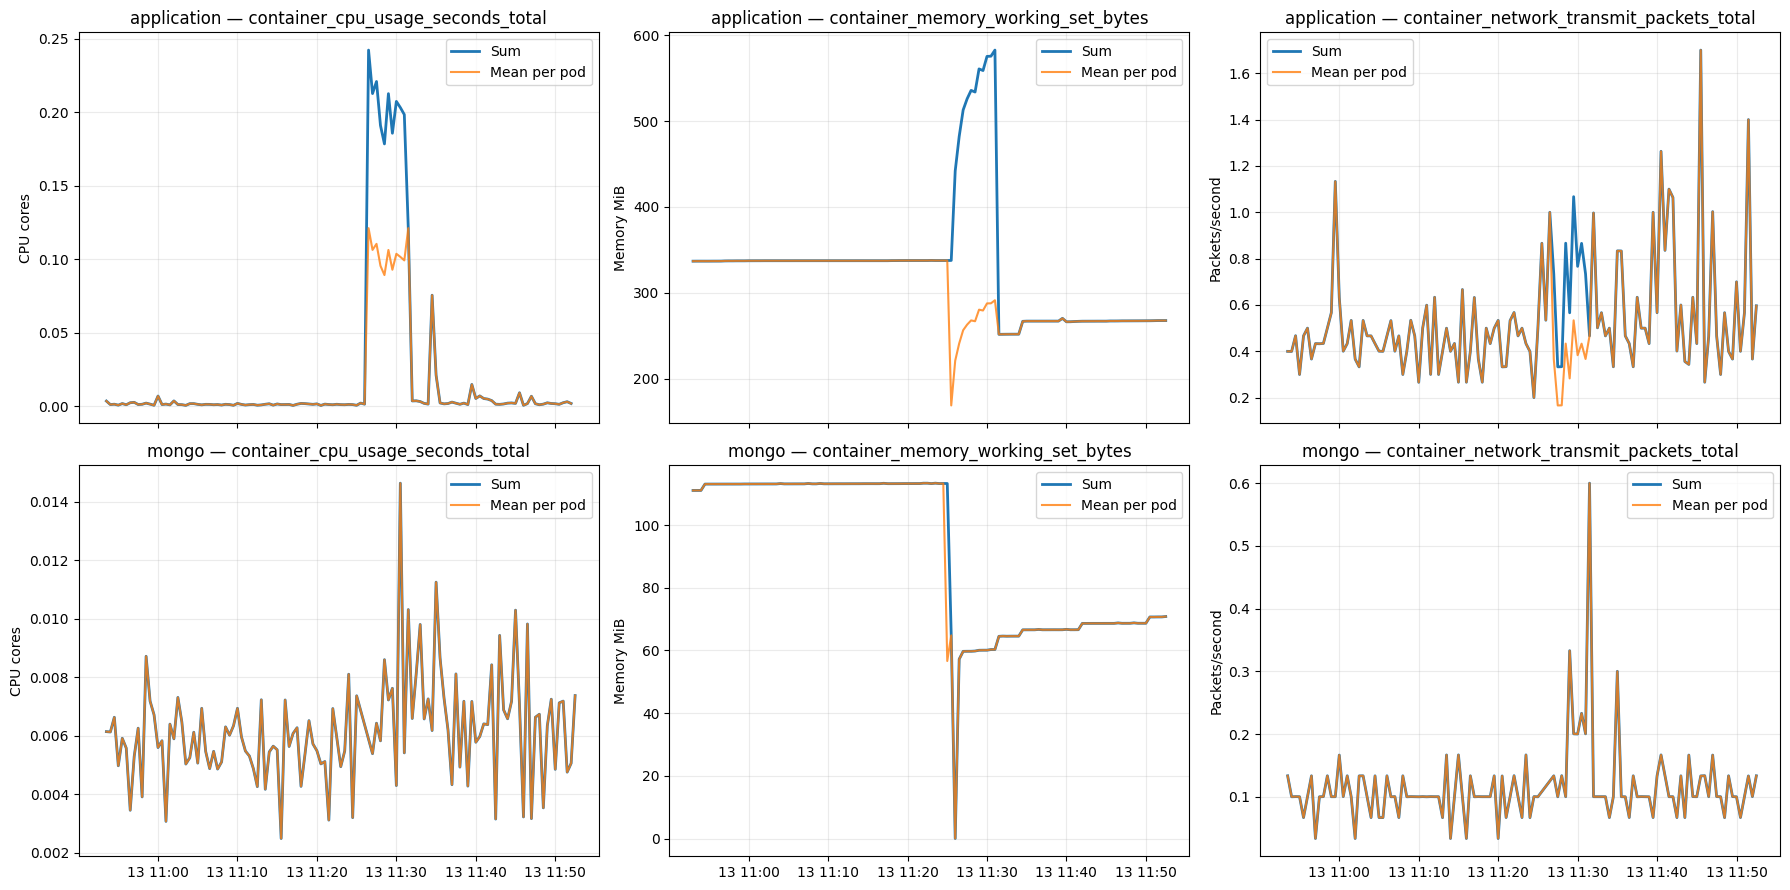

In [6]:
metric_labels = {
    CPU_METRIC: "CPU cores",
    MEMORY_METRIC: "Memory MiB",
    NETWORK_METRIC: "Packets/second",
}

entities = ["application", "mongo"]
metric_order = [CPU_METRIC, MEMORY_METRIC, NETWORK_METRIC]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 9),
    sharex=True,
)

for row_index, entity in enumerate(entities):
    for column_index, metric_name in enumerate(metric_order):
        ax = axes[row_index, column_index]

        data = metric_features[
            metric_features["entity"].eq(entity)
            & metric_features["metric_name"].eq(metric_name)
        ]

        ax.plot(
            data["timestamp"],
            data["value_sum"],
            label="Sum",
            linewidth=2,
        )

        ax.plot(
            data["timestamp"],
            data["value_mean"],
            label="Mean per pod",
            alpha=0.8,
        )

        ax.set_title(f"{entity} — {metric_name}")
        ax.set_ylabel(metric_labels[metric_name])
        ax.grid(alpha=0.25)
        ax.legend()

plt.tight_layout()
plt.show()

## 7. Prepare detection features

Convert aggregate columns into a long-form table so every entity, metric, and feature can be scored independently.

In [7]:
FEATURES_TO_SCORE = [
    "value_sum",
    "value_mean",
    "value_max",
]

feature_long = metric_features.melt(
    id_vars=[
        "timestamp",
        "entity",
        "metric_name",
        "unit",
        "active_pod_count",
        "observed_series_count",
    ],
    value_vars=FEATURES_TO_SCORE,
    var_name="feature_name",
    value_name="observed_value",
)

feature_long = feature_long.sort_values([
    "entity",
    "metric_name",
    "feature_name",
    "timestamp",
])

display(feature_long.head())

,timestamp,entity,metric_name,unit,active_pod_count,observed_series_count,feature_name,observed_value
1418,2022-07-13 10:53:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.003518
1419,2022-07-13 10:54:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.001125
1420,2022-07-13 10:54:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.001367
1421,2022-07-13 10:55:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.000731
1422,2022-07-13 10:55:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.001809


## 8. Detect anomalies with Rolling Median and MAD

Build each baseline from prior observations only and require persistent threshold violations before emitting an anomaly.

In [8]:
ROLLING_WINDOW = 20
MIN_HISTORY = 10
SCORE_THRESHOLD = 4.0

PERSISTENCE_WINDOW = 3
MIN_ANOMALOUS_POINTS = 2


def rolling_mad_detector(group):
    group = group.sort_values("timestamp").copy()

    observed = group["observed_value"].astype(float)

    # shift(1): baseline chỉ sử dụng dữ liệu quá khứ
    history = observed.shift(1)

    rolling = history.rolling(
        window=ROLLING_WINDOW,
        min_periods=MIN_HISTORY,
    )

    expected = rolling.median()

    mad = rolling.apply(
        lambda values: np.median(
            np.abs(values - np.median(values))
        ),
        raw=True,
    )

    robust_scale = 1.4826 * mad
    fallback_std = rolling.std()

    # Tránh scale bằng 0 đối với chuỗi gần như không đổi
    relative_floor = expected.abs() * 0.005
    absolute_floor = pd.Series(1e-9, index=group.index)

    scale = pd.concat(
        [
            robust_scale,
            fallback_std,
            relative_floor,
            absolute_floor,
        ],
        axis=1,
    ).max(axis=1)

    score = (observed - expected) / scale

    candidate = score.abs().ge(SCORE_THRESHOLD)

    persistent = (
        candidate.astype(int)
        .rolling(
            PERSISTENCE_WINDOW,
            min_periods=1,
        )
        .sum()
        .ge(MIN_ANOMALOUS_POINTS)
    )

    group["expected_value"] = expected
    group["scale"] = scale
    group["lower_bound"] = expected - SCORE_THRESHOLD * scale
    group["upper_bound"] = expected + SCORE_THRESHOLD * scale
    group["anomaly_score"] = score
    group["is_candidate"] = candidate
    group["is_anomaly"] = persistent & expected.notna()

    group["direction"] = np.select(
        [
            group["is_anomaly"] & score.gt(0),
            group["is_anomaly"] & score.lt(0),
        ],
        [
            "high",
            "low",
        ],
        default="normal",
    )

    group["detector"] = "rolling_median_mad"

    return group


detected_groups = []

group_columns = [
    "entity",
    "metric_name",
    "feature_name",
]

for _, group in feature_long.groupby(group_columns, sort=False):
    detected_groups.append(rolling_mad_detector(group))

detected = (
    pd.concat(detected_groups, ignore_index=True)
    .sort_values(group_columns + ["timestamp"])
)

display(
    detected[detected["is_anomaly"]]
    .head(30)
)

,timestamp,entity,metric_name,unit,active_pod_count,observed_series_count,feature_name,observed_value,expected_value,scale,lower_bound,upper_bound,anomaly_score,is_candidate,is_anomaly,direction,detector
432,2022-07-13 11:32:00+00:00,application,container_memory_working_set_bytes,MiB,1,1,value_max,251.687500,337.578125,19.122038,261.089972,414.066278,-4.491709,True,True,low,rolling_median_mad
433,2022-07-13 11:32:30+00:00,application,container_memory_working_set_bytes,MiB,1,1,value_max,251.746094,337.550781,26.284464,232.412927,442.688636,-3.264464,False,True,low,rolling_median_mad
661,2022-07-13 11:26:30+00:00,application,container_memory_working_set_bytes,MiB,2,2,value_sum,481.964844,337.578125,23.337617,244.227658,430.928592,6.186866,True,True,high,rolling_median_mad
662,2022-07-13 11:27:00+00:00,application,container_memory_working_set_bytes,MiB,2,2,value_sum,512.875000,337.580078,38.831955,182.252260,492.907897,4.514193,True,True,high,rolling_median_mad
663,2022-07-13 11:27:30+00:00,application,container_memory_working_set_bytes,MiB,2,2,value_sum,525.855469,337.582031,53.054628,125.363518,549.800545,3.548671,False,True,high,rolling_median_mad
1485,2022-07-13 11:26:00+00:00,mongo,container_memory_working_set_bytes,MiB,1,1,value_max,0.000000,113.240234,10.835550,69.898034,156.582435,-10.450806,True,True,low,rolling_median_mad
1486,2022-07-13 11:26:30+00:00,mongo,container_memory_working_set_bytes,MiB,1,1,value_max,57.203125,113.240234,27.017436,5.170490,221.309979,-2.074109,False,True,low,rolling_median_mad
1605,2022-07-13 11:26:00+00:00,mongo,container_memory_working_set_bytes,MiB,1,1,value_mean,0.000000,113.236328,16.226066,48.332065,178.140592,-6.978668,True,True,low,rolling_median_mad
1725,2022-07-13 11:26:00+00:00,mongo,container_memory_working_set_bytes,MiB,1,1,value_sum,0.000000,113.240234,10.835550,69.898034,156.582435,-10.450806,True,True,low,rolling_median_mad
1726,2022-07-13 11:26:30+00:00,mongo,container_memory_working_set_bytes,MiB,1,1,value_sum,57.203125,113.240234,27.017436,5.170490,221.309979,-2.074109,False,True,low,rolling_median_mad


## 9. Visualize detected anomalies

Plot observations, rolling expectations, detection bands, anomaly points, and the inferred deployment transition.

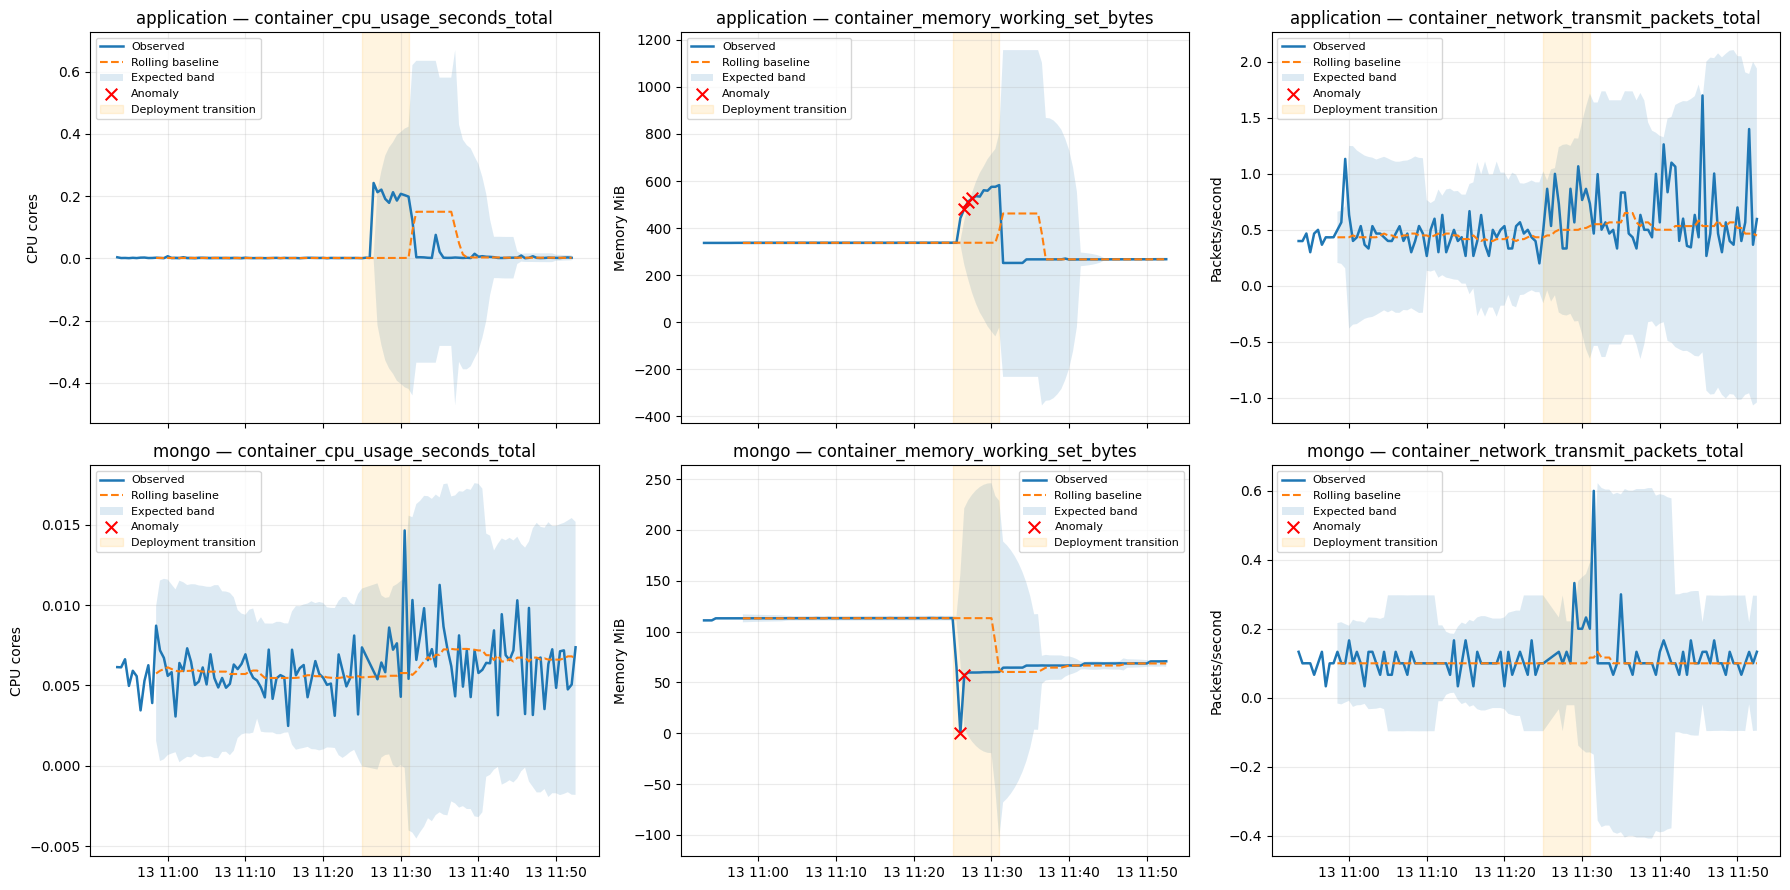

In [9]:
DEPLOYMENT_START = pd.Timestamp(
    "2022-07-13 11:25:00",
    tz="UTC",
)

DEPLOYMENT_END = pd.Timestamp(
    "2022-07-13 11:31:00",
    tz="UTC",
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 9),
    sharex=True,
)

for row_index, entity in enumerate(entities):
    for column_index, metric_name in enumerate(metric_order):
        ax = axes[row_index, column_index]

        data = detected[
            detected["entity"].eq(entity)
            & detected["metric_name"].eq(metric_name)
            & detected["feature_name"].eq("value_sum")
        ].sort_values("timestamp")

        anomalies = data[data["is_anomaly"]]

        ax.plot(
            data["timestamp"],
            data["observed_value"],
            label="Observed",
            linewidth=1.8,
        )

        ax.plot(
            data["timestamp"],
            data["expected_value"],
            label="Rolling baseline",
            linestyle="--",
        )

        ax.fill_between(
            data["timestamp"],
            data["lower_bound"],
            data["upper_bound"],
            alpha=0.15,
            label="Expected band",
        )

        ax.scatter(
            anomalies["timestamp"],
            anomalies["observed_value"],
            color="red",
            marker="x",
            s=70,
            label="Anomaly",
            zorder=5,
        )

        ax.axvspan(
            DEPLOYMENT_START,
            DEPLOYMENT_END,
            color="orange",
            alpha=0.12,
            label="Deployment transition",
        )

        ax.set_title(f"{entity} — {metric_name}")
        ax.set_ylabel(metric_labels[metric_name])
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Review alerts by scenario period

Separate pre-change, deployment-transition, and post-change alerts for descriptive PoC evaluation.

In [10]:
def assign_period(timestamp):
    if timestamp < DEPLOYMENT_START:
        return "pre_change"

    if timestamp <= DEPLOYMENT_END:
        return "deployment_transition"

    return "post_change"


detected["scenario_period"] = (
    detected["timestamp"]
    .map(assign_period)
)

alert_summary = (
    detected
    .groupby(
        [
            "scenario_period",
            "entity",
            "metric_name",
            "feature_name",
        ],
        as_index=False,
    )
    .agg(
        observations=("observed_value", "count"),
        anomaly_points=("is_anomaly", "sum"),
        maximum_score=(
            "anomaly_score",
            lambda x: x.abs().max(),
        ),
    )
)

display(alert_summary)

print("Detected anomaly points:", int(detected["is_anomaly"].sum()))

,scenario_period,entity,metric_name,feature_name,observations,anomaly_points,maximum_score
0,deployment_transition,application,container_cpu_usage_seconds_total,value_max,13,0,575.256394
1,deployment_transition,application,container_cpu_usage_seconds_total,value_mean,13,0,287.606935
2,deployment_transition,application,container_cpu_usage_seconds_total,value_sum,13,0,578.222786
3,deployment_transition,application,container_memory_working_set_bytes,value_max,13,0,1.912741
4,deployment_transition,application,container_memory_working_set_bytes,value_mean,13,0,99.973386
5,deployment_transition,application,container_memory_working_set_bytes,value_sum,13,3,61.814395
6,deployment_transition,application,container_network_transmit_packets_total,value_max,13,0,3.642940
7,deployment_transition,application,container_network_transmit_packets_total,value_mean,13,0,3.642940
8,deployment_transition,application,container_network_transmit_packets_total,value_sum,13,0,3.642940
9,deployment_transition,mongo,container_cpu_usage_seconds_total,value_max,10,0,6.013590


Detected anomaly points: 10


## 11. Produce the detection event contract

Return normalized anomaly evidence for later correlation and incident-building stages.

In [11]:
detection_events = (
    detected[detected["is_anomaly"]]
    [[
        "timestamp",
        "entity",
        "metric_name",
        "feature_name",
        "unit",
        "observed_value",
        "expected_value",
        "lower_bound",
        "upper_bound",
        "anomaly_score",
        "direction",
        "active_pod_count",
        "observed_series_count",
        "scenario_period",
        "detector",
    ]]
    .reset_index(drop=True)
)

display(detection_events)

,timestamp,entity,metric_name,feature_name,unit,observed_value,expected_value,lower_bound,upper_bound,anomaly_score,direction,active_pod_count,observed_series_count,scenario_period,detector
0,2022-07-13 11:32:00+00:00,application,container_memory_working_set_bytes,value_max,MiB,251.687500,337.578125,261.089972,414.066278,-4.491709,low,1,1,post_change,rolling_median_mad
1,2022-07-13 11:32:30+00:00,application,container_memory_working_set_bytes,value_max,MiB,251.746094,337.550781,232.412927,442.688636,-3.264464,low,1,1,post_change,rolling_median_mad
2,2022-07-13 11:26:30+00:00,application,container_memory_working_set_bytes,value_sum,MiB,481.964844,337.578125,244.227658,430.928592,6.186866,high,2,2,deployment_transition,rolling_median_mad
3,2022-07-13 11:27:00+00:00,application,container_memory_working_set_bytes,value_sum,MiB,512.875000,337.580078,182.252260,492.907897,4.514193,high,2,2,deployment_transition,rolling_median_mad
4,2022-07-13 11:27:30+00:00,application,container_memory_working_set_bytes,value_sum,MiB,525.855469,337.582031,125.363518,549.800545,3.548671,high,2,2,deployment_transition,rolling_median_mad
5,2022-07-13 11:26:00+00:00,mongo,container_memory_working_set_bytes,value_max,MiB,0.000000,113.240234,69.898034,156.582435,-10.450806,low,1,1,deployment_transition,rolling_median_mad
6,2022-07-13 11:26:30+00:00,mongo,container_memory_working_set_bytes,value_max,MiB,57.203125,113.240234,5.170490,221.309979,-2.074109,low,1,1,deployment_transition,rolling_median_mad
7,2022-07-13 11:26:00+00:00,mongo,container_memory_working_set_bytes,value_mean,MiB,0.000000,113.236328,48.332065,178.140592,-6.978668,low,1,1,deployment_transition,rolling_median_mad
8,2022-07-13 11:26:00+00:00,mongo,container_memory_working_set_bytes,value_sum,MiB,0.000000,113.240234,69.898034,156.582435,-10.450806,low,1,1,deployment_transition,rolling_median_mad
9,2022-07-13 11:26:30+00:00,mongo,container_memory_working_set_bytes,value_sum,MiB,57.203125,113.240234,5.170490,221.309979,-2.074109,low,1,1,deployment_transition,rolling_median_mad
